
# Lab 4: Predictive Modeling with Decision Trees
### COMM 4259 <br> <i>Foundations of Machine Learning and AI</i>

© Jingjing Li- Ask for permission for using/quoting: jingjing.li@virginia.edu


# Learning Objectives
In this lab we will learn to use **pandas**, **sklearn**, and **matplotlib** to predict wine quality. Specifically, you will learn
- Scikit-learn library
- Build a predictive model
- Assess decision tree performance
    - Evaluate model on training data
    - Evaluate model on test data
- Avoid overfitting by tuning parameters

# Scikit Learn Library
Scikit-learn (formerly scikits.learn and also known as sklearn) is a free software machine learning library for the Python programming language. 

It features various classification, regression and clustering algorithms including support vector machines, random forests, gradient boosting, and k-means, and is designed to interoperate with the Python numerical and scientific libraries NumPy and SciPy.



## Find the scikit-learn version
Run the cell below to print the version of scikit-learn in your environment. Any version 1.0 or newer has the functions this lab uses.

In [5]:
import sklearn
print(sklearn.__version__)

1.5.1


## Check your scikit-learn version
The cell above prints the version of scikit-learn you have. Any version 1.0 or newer runs this lab; the Robertson Hall 317B machines and a current Anaconda install are both fine.

**Do not install a different version.** If the cell above raised an error instead of printing a version, scikit-learn is not installed in the environment your notebook is using. That is almost always the wrong kernel rather than a missing package: choose <code>base (anaconda3)</code> from **Select Kernel** at the top right and run the cell again. If it still fails, bring it to a TA or to office hours rather than installing packages during the lab.

## Import libraries
Sklearn contains multiple pakages. Decision tree algorithms are in **sklearn.tree**. Evaluation functions are at **sklearn.metrics**.

**Matplotlib** is one of the earliest python libraries for plotting. You can think it as the "grandfather" of seaborn. It is useful for some complicated plotting scenarios.

In [1]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
# %matplotlib inline   <- not needed: Jupyter shows plots on its own, and this line hides them on Anaconda 2024.10

from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
from sklearn.tree import export_text
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Ignore useless warnings (see SciPy issue #5998)
import warnings
warnings.simplefilter("ignore", UserWarning)

In [2]:
# Fix the precision for real number print in this notebook
%precision 4

'%.4f'

# The Wine Quality Dataset
A wine manufacturer has asked you to develop a model capable of predicting customers’ perceived quality for a particular wine based on its ingredients. The dataset contains 11 independent variables and a target variable (i.e., class label = quality). Quality, which was derived by aggregating customer survey responses, originally included values on a 1-10 scale. For this task, the data has been simplified to a binary classification problem (i.e., with quality being “good” or “poor”). Your task is to build a model that can best predict whether a wine will be regarded as good or poor. 

As the analyst, you must determine the ideal model settings (e.g., criterion, maximal depth, leaf size, etc.). You may manipulate any/all model parameter settings.

# Data Preparation
## Read Data

In [4]:
# Load data and store it into pandas DataFrame objects
df = pd.read_csv("WineQuality.csv")
print(df.shape)
df.head()

(1809, 12)


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,8.0,0.45,0.36,8.8,0.026,50.0,151.0,0.99270,3.07,0.25,12.7,Good
1,8.3,0.21,0.41,2.2,0.050,24.0,108.0,0.99400,2.85,0.45,9.5,Poor
2,7.6,0.27,0.29,2.5,0.059,37.0,115.0,0.99328,3.09,0.37,9.8,Poor
3,6.0,0.18,0.31,1.4,0.036,14.0,75.0,0.99085,3.34,0.58,11.1,Good
4,7.0,0.14,0.28,1.3,0.026,10.0,56.0,0.99352,3.46,0.45,9.9,Poor


<Axes: xlabel='quality', ylabel='count'>

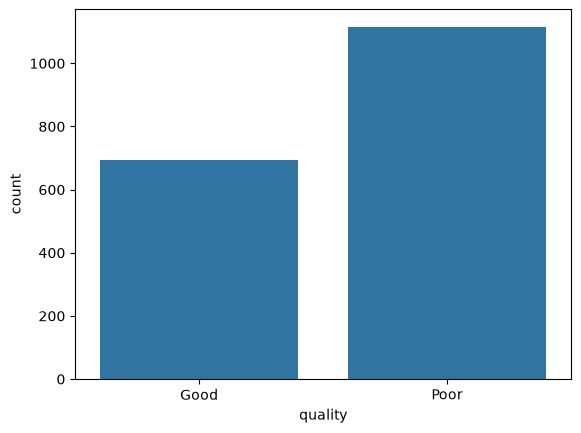

In [5]:
# Obtain the distribution of the class labels
sns.countplot(x = "quality", data = df)

## Segment data into features (X) and class label (y)

In [6]:
# Define class labels
tname = "quality"

# Create a dataframe for input attributes
X = df.drop(tname, axis = 1)

# Create a dataframe for class labels
y = df[tname]

## Obtain the list of feature names and values for class labels

This is used for tree visualization functions later

In [7]:
# Obtain attribute(feature) names (used for tree visualization)
fnames = list(X.columns)
print(fnames)

# Obtain class label names (used for tree visualization)
cnames = np.sort(y.unique())
print(cnames)

['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol']
['Good' 'Poor']


## Split the labeled data into training and test data
random_state is the seed used by the random number generator. Make sure to use the same random_state seed number. Otherwise the data splitting will be different!

In [8]:
# Split the data into training (67%) and testing (33%). 
# Random_state is to make sure the results are consistent across different runs
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.33, random_state = 1)

# Build a Predictive Model

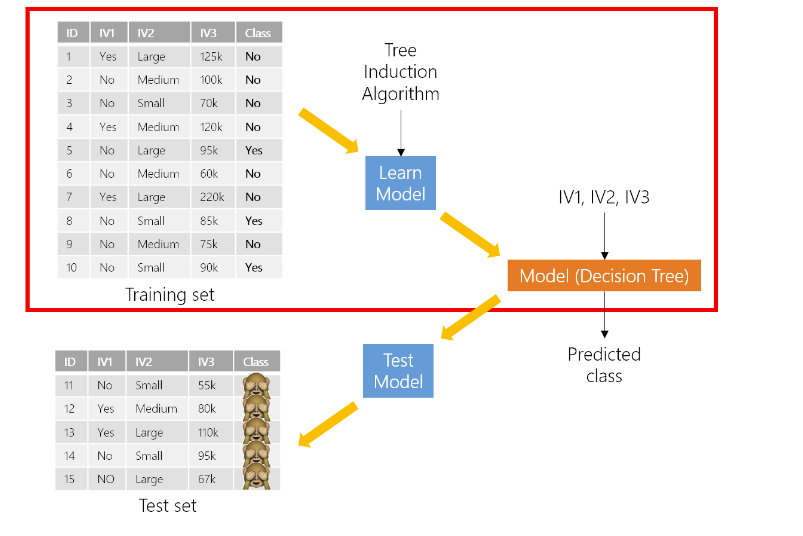

## Build the decision tree from the training data
**max_depth** and **random_state** are the parameters for this decision. Check this DecisionTreeClassifier [Documentation](https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html) to understand a list of parameter options.

In [9]:
# Defining and fitting a DecisionTreeClassifier instance
dt = DecisionTreeClassifier(max_depth = 2, criterion = "entropy", random_state = 1)
dt = dt.fit(X_train,y_train)

## Understand Decision Tree 
We will plot tress and show prediction rules to help you understand decision tree.
### Visualize the decision tree (using sklearn's plot_tree)
Use the **plot_tree** function to visualize the decision tree.

Notice that the plot_tree function is not available for sklearn version earlier than 0.22.1. For information about plot_tree function, read this [Documentation](https://scikit-learn.org/stable/modules/generated/sklearn.tree.plot_tree.html).

We use **matplotlib** to control the size of the visualization. If you are interested in knowing more about matplotlib, you can watch this [video](https://www.youtube.com/watch?v=XFZRVnP-MTU).

We need to let **plot_tree** function to know the feature names and class label values, otherwise it just shows feature and label index (unreadable). **rounded** changed the shape of the tree nodes. **filled** color codes the tree nodes. **ax** allows us to use matplotlib to adjust the figure size. 

**savefig** will save the tree visualization as a file. Common formats include pdf, png, jpeg. 


In [10]:
# Define a function to visualize a decision tree model and save it in a file (pdf, jpeg, png etc.)
def viz_tree_fig(dt, fnames, cnames, figname=None, show=True):
    fig, ax = plt.subplots(figsize=(10, 10))
    plot_tree(
        dt,
        feature_names=fnames,
        class_names=[str(c) for c in cnames],  # ensure strings
        rounded=True,
        filled=True,
        ax=ax
    )
    fig.tight_layout()

    if figname:  # save if a filename is provided
        fig.savefig(figname, bbox_inches="tight")

    if show:     # display in the notebook
        display(fig)

    plt.close(fig)  # avoid duplicate displays in later cells

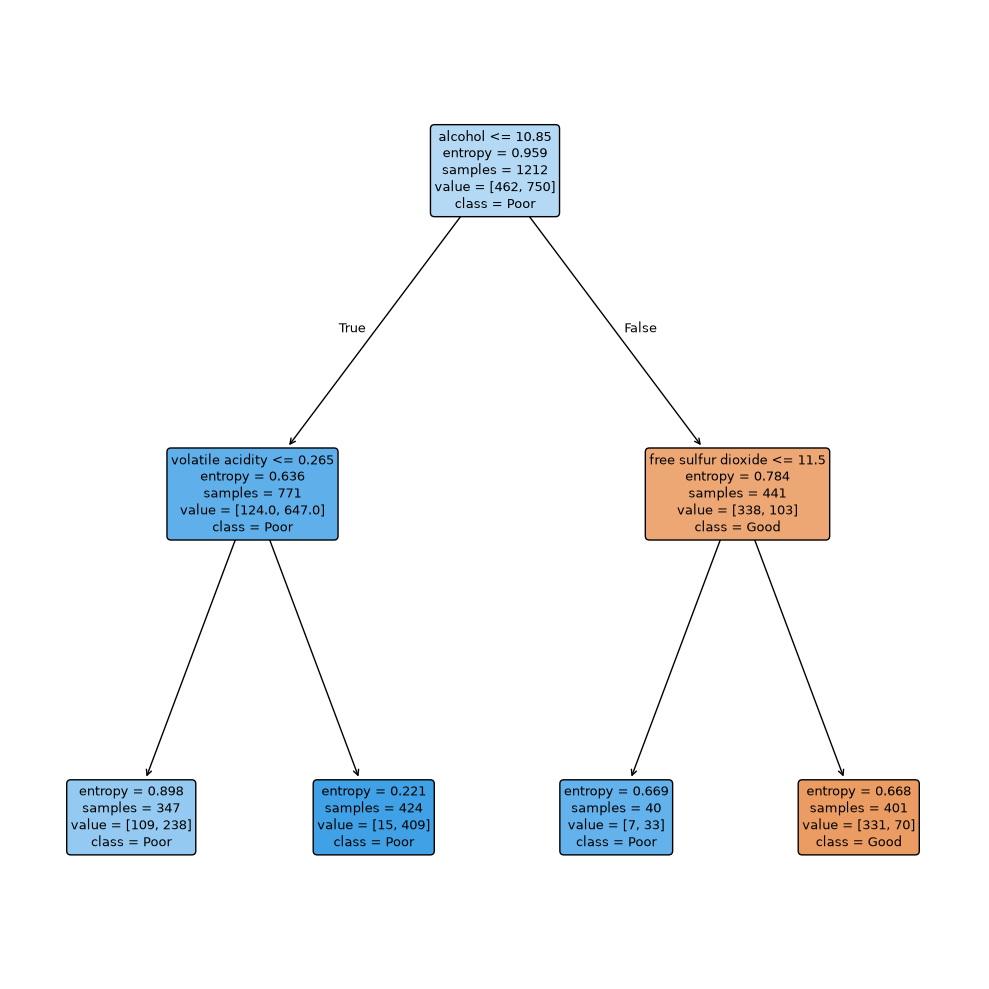

In [11]:
# Call the viz_tree function
viz_tree_fig(dt, fnames, cnames, "tree_dep-3_entropy.pdf")

### Show the Decision Tree rules in a text output
We will use the **export_text** function to show the classification rules in a text format. This is useful when your tree is large. You can learn more about export_text function by reading this [Documentation](https://scikit-learn.org/stable/modules/generated/sklearn.tree.export_text.html).
We can write the text output into a text file by using the with open statement

In [12]:
# Define a function to print decision tree rules and save it in a text file
def save_tree_text(dt, fnames, txtname):
    r = export_text(dt, feature_names = fnames, show_weights = True)
    print(r)
    with open(txtname,"w") as outfile:
        outfile.write(r)

In [13]:
# Call the save_tree_text function
save_tree_text(dt, fnames, "tree_dep-3_entropy.txt")

|--- alcohol <= 10.85
|   |--- volatile acidity <= 0.27
|   |   |--- weights: [109.00, 238.00] class: Poor
|   |--- volatile acidity >  0.27
|   |   |--- weights: [15.00, 409.00] class: Poor
|--- alcohol >  10.85
|   |--- free sulfur dioxide <= 11.50
|   |   |--- weights: [7.00, 33.00] class: Poor
|   |--- free sulfur dioxide >  11.50
|   |   |--- weights: [331.00, 70.00] class: Good



# Exercise 1: Interpret the Decision Tree

<div style="background-color:#DFF5DC; color:#14532D; border:1px solid #A5D6A7; border-left:5px solid #2E7D32; padding:15px; margin-bottom:20px; border-radius:4px;">
Based on the text output above, use plain English to describe the four prediction rules for wine quality.
</div>

If alcohol <= 10.85 and volatile acidity <= 0.265, predict Poor quality.
If alcohol <= 10.85 and volatile acidity > 0.265, predict Poor quality.
If alcohol > 10.85 and free sulfur dioxide <= 11.5, predict Poor quality.
If alcohol > 10.85 and free sulfur dioxide > 11.5, predict Good quality.

# Assess Performance of Decision Tree
- Visually inspecting a Decision Tree model can provide insights into the intuition behind various production rules.
- However it is difficult to say how accurate/effective the tree is.
- Need to:
    - Evaluate accuracy on training data
    - Evaluate accuracy on test data





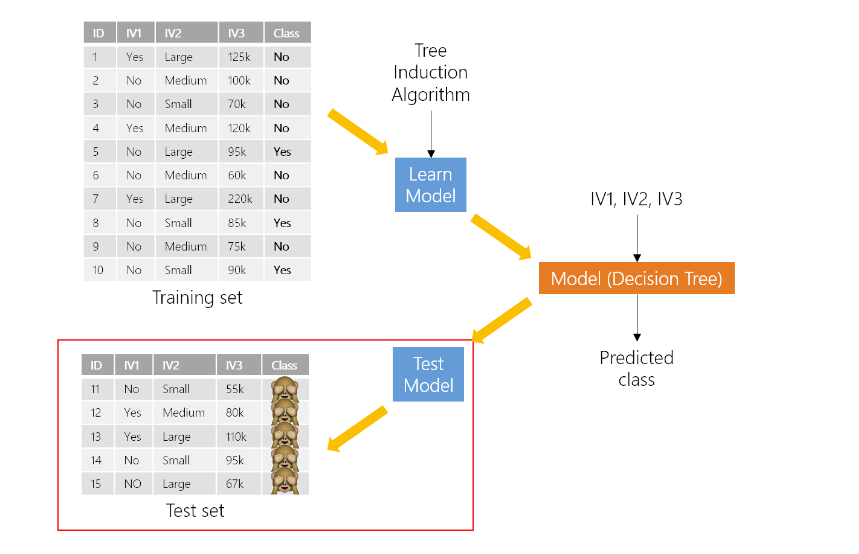

We can use the **predict** function to apply the decision tree model to a dataset. It will output the predicted outcomes. You can evaluate the model performance by comparing the **predicted** and **actual** outcome.

We can use the **accuracy_score** from sklearn.metrics to calculate the accuracy score

## Evaluate model on training data

In [14]:
y_pred_train = dt.predict(X_train)
accuracy_score(y_train, y_pred_train)

0.8342

## Evaluate model on test data

We need to use the test data to test the model performance becase the model is likely to perform better on the SAME data that was used to build the model

In [15]:
y_pred_test = dt.predict(X_test)
accuracy_score(y_test, y_pred_test)

0.8107

## (Advanced) Show the true and predicted labels, as well as predicted probabilites in a dataframe

We can use the **predict_proba** function to get the classification probabilites (you can think them as confidence scores) for each class. For example, given an instance, if positive probability is greater than negative probability, the final prediction label will be "positive".

There is no convenient way to show them at once, but you can use pandas to prepare the data.

In [16]:
# Define a function to print the predicted outcomes and probabilites
def show_pred_prob (y_test, y_pred_test, X_test):
    y_true_df = pd.DataFrame(y_test).reset_index(drop = True)
    y_pred_df = pd.DataFrame(y_pred_test, columns = ["y_pred"])
    y_pred_prob = pd.DataFrame(dt.predict_proba(X_test, check_input=True), columns = dt.classes_)
    predictions = pd.concat([y_true_df, y_pred_df, y_pred_prob], axis = 1)
    return predictions

In [17]:
# Print a dataframe with predicted outcomes and probabilities
#pd.set_option('display.max_rows', None)
prob_df = show_pred_prob(y_test, y_pred_test, X_test)
prob_df.sort_values(by = "Poor", ascending = False)

,quality,y_pred,Good,Poor
0,Poor,Poor,0.035377,0.964623
304,Poor,Poor,0.035377,0.964623
325,Poor,Poor,0.035377,0.964623
323,Poor,Poor,0.035377,0.964623
317,Poor,Poor,0.035377,0.964623
...,...,...,...,...
439,Poor,Good,0.825436,0.174564
440,Poor,Good,0.825436,0.174564
264,Good,Good,0.825436,0.174564
263,Good,Good,0.825436,0.174564








# Decision Tree (putting all the codes together)

<div style="background-color:#FFF4CE; color:#5C4200; border:1px solid #E8C86E; border-left:5px solid #D69E00; padding:15px; border-radius:4px;">
<b>Let us combine all the codes together</b><br> 

In the codes above, I split the decision tree building codes into multiple code cells for a line-by-line explanation. Next, let me show you how to combine codes into fewer code cells for a higher level of readability.
</div>








### Define Functions (Only include them if you need to visualize decision trees or interpret prediction rules)

In [18]:
# Define a function to visualize a decision tree model and save it in a file (pdf, jpeg, png etc.)
def viz_tree_fig(dt, fnames, cnames, figname=None, show=True):
    fig, ax = plt.subplots(figsize=(10, 10))
    plot_tree(
        dt,
        feature_names=fnames,
        class_names=[str(c) for c in cnames],  # ensure strings
        rounded=True,
        filled=True,
        ax=ax
    )
    fig.tight_layout()

    if figname:  # save if a filename is provided
        fig.savefig(figname, bbox_inches="tight")

    if show:     # display in the notebook
        display(fig)

    plt.close(fig)  # avoid duplicate displays in later cells

# Define a function to print decision tree rules and save it in a text file
def save_tree_text(dt, fnames, txtname):
    r = export_text(dt, feature_names=fnames, show_weights = True)
    print(r)
    with open(txtname,"w") as outfile:
        outfile.write(r)

### Import Libraries

In [19]:
import pandas as pd
import seaborn as sns
import numpy as np

from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
from sklearn.tree import export_text
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

import matplotlib.pyplot as plt
# %matplotlib inline   <- not needed: Jupyter shows plots on its own, and this line hides them on Anaconda 2024.10

# Ignore useless warnings (see SciPy issue #5998)
import warnings
warnings.simplefilter("ignore", UserWarning)

### Data Prep

In [20]:
df = pd.read_csv("WineQuality.csv")

# Define class labels
tname = "quality"

# Create a dataframe for input attributes
X= df.drop(tname, axis = 1)

# Create a dataframe for class labels
y = df[tname]

# Obtain attribute(feature) names (used for tree visualization)
fnames = list(X.columns)

# Obtain class label names (used for tree visualization)
cnames = np.sort(y.unique())

# Split the data into training (67%) and testing (33%). 
# Random_state is to make sure the results are consistent across different runs
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state = 1)

### Build and Evaluate Decision Trees

In [21]:
# Build a decision tree with default parameter.
dt = DecisionTreeClassifier(random_state = 1)

# Train a tree based on the training data
dt = dt.fit(X_train,y_train)

# Visualize the decision tree (optional)
# viz_tree_fig(dt, fnames, cnames, "tree_big.pdf")
# save_tree_text(dt, fnames, "tree_big.txt")

# Calculate training accuracy
y_pred_train = dt.predict(X_train)
print(f"Training accuracy for the default decision tree is: {accuracy_score(y_train, y_pred_train):.4f}")

# Calculate testing accuracy
y_pred_test = dt.predict(X_test)
print(f"Testing accuracy for the default decision tree is: {accuracy_score(y_test, y_pred_test):.4f}")

Training accuracy for the default decision tree is: 1.0000
Testing accuracy for the default decision tree is: 0.8543


# Tradeoff between Underfitting and Overfitting




<div style="background-color:#FFF4CE; color:#5C4200; border:1px solid #E8C86E; border-left:5px solid #D69E00; padding:15px; border-radius:4px;">
<b>Tune Decision Tree Parameters </b><br> 

Now, we know how to build a decision tree using default parameters. Let's learn how to tune the tree parameters to get a better tree (more accurate and generalizable).</div>


## Gap between training and test accuracy
- Performance on test data will generally be lower than that on training data.
- This is because the model is obviously likely to perform better on the SAME data that was used to build the model!
- The real question is HOW MUCH WORSE performance is on the test data relative to the training data.
- A larger, widening gap (across different parameter settings) signifies potential overfitting

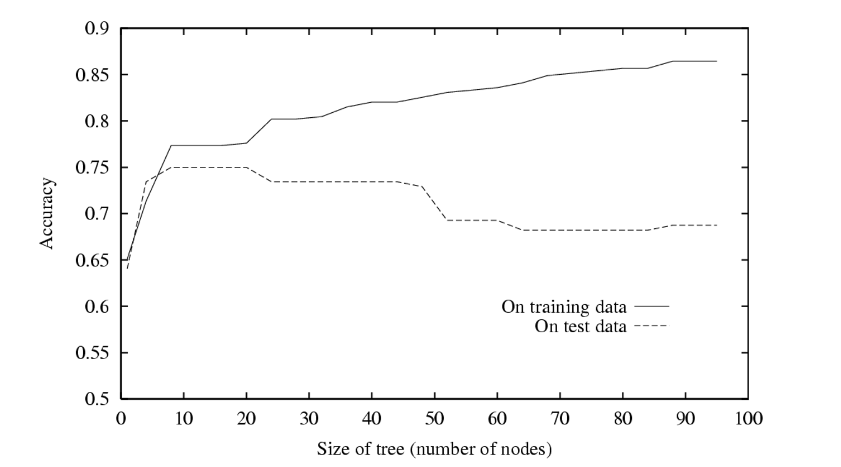

## Overfitting for the Wine Quality Data
Let's try trees with different max_depth (from 1 to 30) and look at the gap between training and test accuracy.

In [22]:
train_acc = []
test_acc = []
size = []
maximal_depth = range(1,30)

# Build decision trees with different maximal depth (1 to 30)
for i in maximal_depth:
    # Define a decision tree
    dt = DecisionTreeClassifier(max_depth = i, 
                                min_impurity_decrease = 0.001, 
                                criterion = 'entropy',
                                random_state = 1)
    # Tree on the training data
    dt = dt.fit(X_train, y_train)
    
    # Obtain training accuracy
    y_pred_train = dt.predict(X_train)
    train_acc.append(accuracy_score(y_train, y_pred_train))
    
    # Obtain testing accuracy
    y_pred_test = dt.predict(X_test)
    test_acc.append(accuracy_score(y_test, y_pred_test)) 

    #Obtain tree size
    size.append(dt.tree_.node_count)

# Log the tree size, training and test accuracy for each tree and store them in a dataframe
tree_log = {'size':size, 'train_acc':train_acc, 'test_acc':test_acc}
df = pd.DataFrame(tree_log) 
df.head(10)

,size,train_acc,test_acc
0,3,0.812706,0.798995
1,7,0.834158,0.810720
2,15,0.837459,0.812395
3,31,0.864686,0.825796
4,49,0.882013,0.824121
5,73,0.894389,0.852596
6,95,0.915017,0.844221
7,117,0.940594,0.840871
8,143,0.950495,0.840871
9,169,0.971947,0.840871


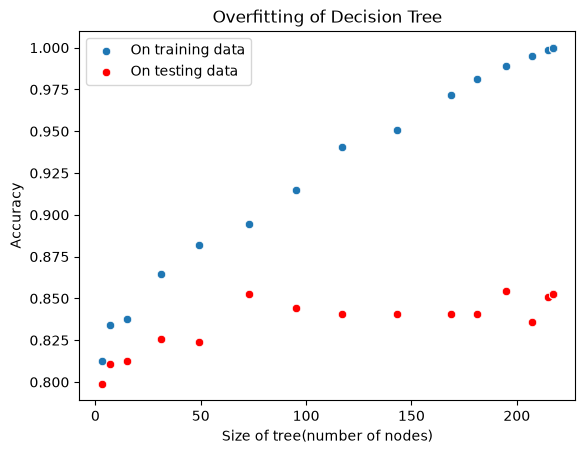

In [23]:
#Visualize the relationship between tree size, training and test accuracy
sns.scatterplot(x = "size", y = "train_acc", data = df, label = 'On training data')
sns.scatterplot(x = "size", y = "test_acc", data = df, label = 'On testing data', 
                color = 'r').set(xlabel = 'Size of tree(number of nodes)', ylabel = "Accuracy", 
                                 title = "Overfitting of Decision Tree")
plt.savefig("overfitting.png")

# Tuning Decision Tree Parameters to Get the Right-Sized Tree

## Pruning
**Pruning** is a process of removing the parts of the tree which adds very little to the classification power of the tree.

Pruning is done with two things in mind :

- Reducing the complexity
- Reducing the chances of overfitting


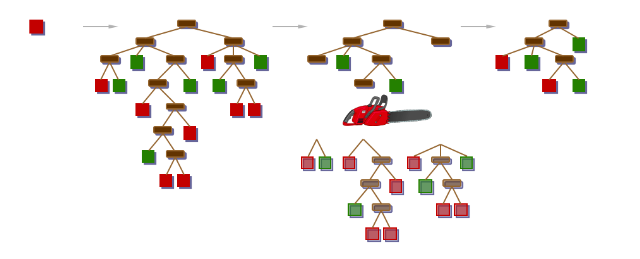

## Prune Trees by Tuning the parameters

There are several parameters governing the tree size. You can read this [Documentation](https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html) to learn about these parameters.

**We will illustrate the following parameters:**
- max_depth
- max_leaf_nodes
- min_samples_leaf (the smaller, the bigger the tree is)
- min_samples_split (the smaller, the bigger the tree is)
- min_impurity_decrease (the smaller, the bigger the tree is)

In addition, **criterion** determines the impurity measurement. 

Both Gini Impurity and Entropy are criteria to split a node in a decision tree. They are standard metrics to compute “impurity” or “information level”. They guide to split a node in the decision tree only based on the information that exists at that node. 

### Obtain a list of tree parameters
```Python
dt.get_params()
```

### Get the number of leaves
```python
dt.get_n_leaves()
```

### Get the depth of the tree
```python
dt.get_depth()
```

### Build and Evaluate Decision Trees (Default Parameters)

In [24]:
# Build a decision tree with default parameter.
dt = DecisionTreeClassifier(random_state = 1)

# Train a tree based on the training data
dt = dt.fit(X_train,y_train)

# Print decision tree parameters, leaves and depth
print(f"The tree parameters are: {dt.get_params()}")
print(f"The number of leaves is: {dt.get_n_leaves()}")
print(f"The depth of the tree is: {dt.get_depth()}")

# Calculate training accuracy
y_pred_train = dt.predict(X_train)
print(f"Training accuracy for the default decision tree is: {accuracy_score(y_train, y_pred_train):.4f}")

# Calculate testing accuracy
y_pred_test = dt.predict(X_test)
print(f"Testing accuracy for the default decision tree is: {accuracy_score(y_test, y_pred_test):.4f}")

The tree parameters are: {'ccp_alpha': 0.0, 'class_weight': None, 'criterion': 'gini', 'max_depth': None, 'max_features': None, 'max_leaf_nodes': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'random_state': 1, 'splitter': 'best'}
The number of leaves is: 119
The depth of the tree is: 14
Training accuracy for the default decision tree is: 1.0000
Testing accuracy for the default decision tree is: 0.8543


### Build and Evaluate Decision Trees (Tuned Parameters)

In [25]:
# Build a decision tree with tuned parameters
dt = DecisionTreeClassifier(max_depth = 5,
                            max_leaf_nodes = None, 
                            min_impurity_decrease = 0.001, 
                            min_samples_leaf = 1, 
                            min_samples_split = 2,
                            random_state = 1)


# Train a tree based on the training data
dt = dt.fit(X_train,y_train)

# Print decision tree parameters, leaves and depth
print(f"The tree parameters are: {dt.get_params()}")
print(f"The number of leaves is: {dt.get_n_leaves()}")
print(f"The depth of the tree is: {dt.get_depth()}")

# Calculate training accuracy
y_pred_train = dt.predict(X_train)
print(f"Training accuracy for the default decision tree is: {accuracy_score(y_train, y_pred_train):.4f}")

# Calculate testing accuracy
y_pred_test = dt.predict(X_test)
print(f"Testing accuracy for the default decision tree is: {accuracy_score(y_test, y_pred_test):.4f}")

The tree parameters are: {'ccp_alpha': 0.0, 'class_weight': None, 'criterion': 'gini', 'max_depth': 5, 'max_features': None, 'max_leaf_nodes': None, 'min_impurity_decrease': 0.001, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'random_state': 1, 'splitter': 'best'}
The number of leaves is: 24
The depth of the tree is: 5
Training accuracy for the default decision tree is: 0.8911
Testing accuracy for the default decision tree is: 0.8593


Regularizing the size of tree can reduce the risk of overfitting (shrinking the gap between training and testing accuracy and improve testing accuracy)

# (Optional) Exercise 2: Tuning Decision Tree Parameters
Refer to the "Overfitting" codes

<div style="background-color:#DFF5DC; color:#14532D; border:1px solid #A5D6A7; border-left:5px solid #2E7D32; padding:15px; margin-bottom:20px; border-radius:4px;">
1. Use a for-loop to change the max_leaf_nodes of the default tree (random_state = 1) from 10, 20, 50, 100, and 150, visualize the training and testing accuracies using a scatterplot and comment how these two accuracies change based on max_leaf_nodes
<br>2. Use the same method to figure out the relationship between training/test accuracy and min_samples_leaf and min_samples_split, min_impurity_decrease
</div>